# Reinforcement Learning Demo

In [2]:
import gymnasium as gym
import pandas
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

def warn(*args, **kwargs):
    return None

warnings.warn = warn

**NOTE**: This notebook has been updated to use `gymnasium` instead of `gym` as `gym` is unsupported since 2022.

We'll use the simple game `FrozenLake`, which consists of a 4x4 grid of tiles with the following mapping:
- F -> Frozen lake
- S -> Start Tile
- G -> Goal Tile
- H -> Hole

The goal is to move from the start tile to the goal without falling into the hole. The lake is frozen so the player may encounter slippery tiles which inhibit the movement and may cause the player to fall in the hole.

(0, {'prob': 1})


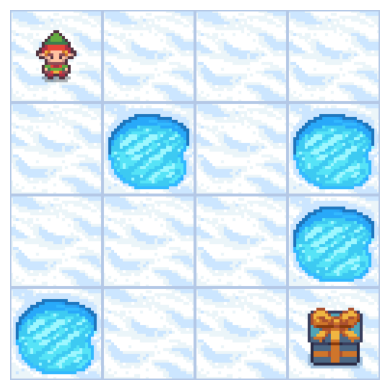

In [3]:
# Build an environment with gym.make()
env = gym.make('FrozenLake-v1', render_mode="rgb_array_list") # Build a fresh environment

# Start a new game with env.reset()
current_observation = env.reset() # This starts a new "episode" and returns the initial observation

# The current observation is just the current location
print(current_observation) # Observations are just a number

def show_frozen_lake(env):
    plt.figure(figsize=(4, 4))
    plt.axis('off')
    plt.tight_layout()
    plt.imshow(env.render()[0])

show_frozen_lake(env)

In [4]:
# the action space for this environment includes four discrete actions
print(f"our action space: {env.action_space}")
new_action = env.action_space.sample() # we can randomly sample actions
print(f"our new action: {new_action}") # run this cell a few times to get an idea of the action space
# what does it look like?

our action space: Discrete(4)
our new action: 0


So we can display a representation of the game board and sample actions from a set of allowed actions. In this case, the discrete actions space is 4-dimensional. This corresponds to the 4 cardinal directions the player can move in.

The mapping is:
- 0 -> left
- 1 -> down
- 2 -> right
- 3 -> up

The observation space is represented by an integer, calculated as an index into the tiles: `tile_position = current_row * ncols + current_col`.
The player starts at [0, 0], which corresponds to `tile_position = 0`.

The rewards for the system are:
- Reach Goal -> +1
- Fall in hole -> 0
- Reach Frozen -> 0

The termination condition is either when the player reaches the goal, falls in the hole, or after 100 rounds.

The `is_slippery` parameter can be passed to the constructor. in this case the movements are not deterministic, but come with a transition probability due to the slippery nature of the frozen lake tiles. The player will then move in the intended direction with a probability of `success_rate`. And in either perpendicular direction with half of the remaining success rate.

### Performing Actions

To perform actions, the `gymnasium` api provodes the `.step()` function for each environment. Below a random action is sampled and performed on the environment. The step function returns a tuple of the following shape: `(observation, reward, done, info, properties)`. In this case the observation is `tile_position` as defined above. The reward is a value of 0 or 1, depending on failure state. The `done` boolen communicates whether the current run is terminated. The `info` option is not used in this case. The `properties` dictionary holds the transition probability used when `is_slippery` is True. 

observation: 4, reward: 0, done: False, info: False, properties: {'prob': 0.3333333333333333}


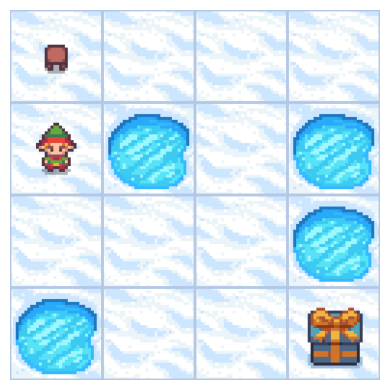

In [5]:
# now we act! do this with the step function
new_action = env.action_space.sample()

observation, reward, done, info, props = env.step(new_action)

# here's a look at what we get back
print(f"observation: {observation}, reward: {reward}, done: {done}, info: {info}, properties: {props}")

show_frozen_lake(env)

Now we can reset the environment and loop a few steps.

observation: 0, reward: 0, done: False, info: False
observation: 0, reward: 0, done: False, info: False
observation: 0, reward: 0, done: False, info: False
observation: 0, reward: 0, done: False, info: False
observation: 4, reward: 0, done: False, info: False


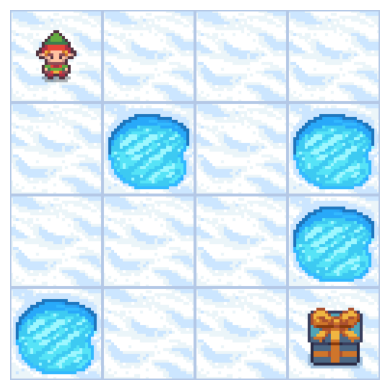

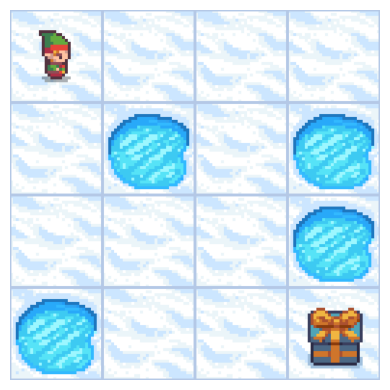

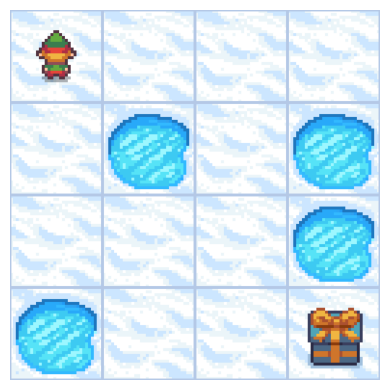

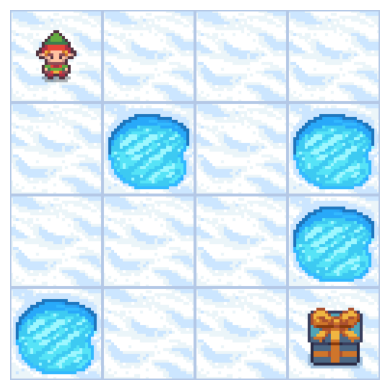

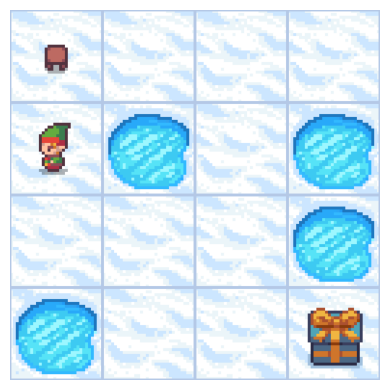

In [6]:
current_observation = env.reset() # start a new game

for i in range(5): # run 5 moves

    new_action = env.action_space.sample() # same a new action
    observation, reward, done, info, props = env.step(new_action) # step through the action and get the outputs
    print(f"observation: {observation}, reward: {reward}, done: {done}, info: {info}")
    show_frozen_lake(env)

Just randomly making moves is unlikely to get to the goal. So the example above usually results in not much movement at all (due to repeatedly running into walls), or failure (due to falling in the hole).

This is not very useful. So this is where reinforcement learning comes in. The goal is to build an agent that can reliably read the environment and make informed decisions on what move to take. 

## Gathering Data

First we need to gather initial data to feed the agent. For this we'll simply run the random algorithm from above a bunch of times and store it as a history.

For this we will run the random trial 40_000 times and store the results in a dataframe of shape [Observation, Action, Reward, Episode] Episode is the equivalent of an epoch from other learning methods. Usually this means "a period of learning in which the model has seen all data", but this is a fuzzy concept in reinforcement learning since not the entire space will be seen during training. Therefore an *Episode* is a single complete run of a game or environment simulation.

Below `ep_memory` holds the entire chain for a single episode. This is then appended with the total reward (in this game, the only possible reward per episode is 1), and a decayed total reward. The decayed total reward is such that it becomes progressively lower throughout the episode. This way the model learns to favor moves that initially move it towards a favorable configuration (begin able to reach the goal tile).

In [7]:
env = gym.make('FrozenLake-v1')

num_episodes = 40000

life_memory = []
for i in range(num_episodes):
    
    # start a new episode and record all the memories
    old_observation, info = env.reset()
    done = False
    tot_reward = 0
    ep_memory = []

    # run the simulation until failure or success
    while not done:
        new_action = env.action_space.sample()
        observation, reward, done, _, info = env.step(new_action)
        tot_reward += reward
        
        ep_memory.append({
            "observation": old_observation,
            "action": new_action,
            "reward": reward,
            "episode": i,
        })
        old_observation = observation
        
    # incorporate total reward
    num_steps = len(ep_memory)
    for i, ep_mem in enumerate(ep_memory):
        ep_mem["tot_reward"] = tot_reward
        ep_mem["decay_reward"] = 1 - i*tot_reward/num_steps
        
    life_memory.extend(ep_memory)
    
memory_df = pandas.DataFrame(life_memory)

In [8]:
memory_df.describe()

,observation,action,reward,episode,tot_reward,decay_reward
count,306749.00000,306749.000000,306749.000000,306749.000000,306749.000000,306749.000000
mean,2.23398,1.498724,0.001832,19981.157692,0.023941,0.988945
std,3.00298,1.118716,0.042764,11544.626749,0.152867,0.083486
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.019231
25%,0.00000,0.000000,0.000000,9995.000000,0.000000,1.000000
50%,1.00000,1.000000,0.000000,20014.000000,0.000000,1.000000
75%,4.00000,2.000000,0.000000,30045.000000,0.000000,1.000000
max,14.00000,3.000000,1.000000,39999.000000,1.000000,1.000000


In [9]:
memory_df.groupby("episode").reward.sum().mean()

np.float64(0.01405)

In [10]:
memory_df[memory_df["tot_reward"] == 1].head(20)

,observation,action,reward,episode,tot_reward,decay_reward
103,0,2,0,12,1,1.000000
104,1,3,0,12,1,0.875000
105,2,1,0,12,1,0.750000
106,6,2,0,12,1,0.625000
107,10,1,0,12,1,0.500000
108,9,2,0,12,1,0.375000
109,13,1,0,12,1,0.250000
110,14,3,1,12,1,0.125000
884,0,3,0,117,1,1.000000
885,0,3,0,117,1,0.916667


From the description of the data above it is clear that the reward is extremely low. Meaning that the completely random agent did not reach the goal most of the times. 

## Prediction

Since the environment is fixed in this case, we can simply use the historical data and don't need explicit knowledge of the environment. It is possible to devise a cost function that predicts which moves perform well.

In this case it is essentially a form of supervised learning since we use labelled data (the reward begin the label) to train our model. But this preliminary model can be used to feed followup systems that are more RL learning based.

In [11]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

model = ExtraTreesRegressor(n_estimators=50)
# model = SVR()
y = 0.5*memory_df.reward + 0.1*memory_df.decay_reward + memory_df.tot_reward
x = memory_df[["observation", "action"]]
model.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the n

In [12]:
model = RandomForestRegressor()
y = 1*memory_df.reward + memory_df.tot_reward + .1*memory_df.decay_reward
x = memory_df[["observation", "action"]]
model.fit(x, y)

num_episodes = 500
random_per = 0

life_memory = []
for i in range(num_episodes):
    # Start a new episode and record all the memories.
    old_observation, _ = env.reset()
    done = False
    tot_reward = 0
    ep_memory = []
    while not done:
        if np.random.rand() < random_per:
            new_action = env.action_space.sample()
        else:
            pred_in = [[old_observation,i] for i in range(4)]
            new_action = np.argmax(model.predict(pred_in))
        observation, reward, done, _, info = env.step(new_action)
        tot_reward += reward
        
        ep_memory.append({
            "observation": old_observation,
            "action": new_action,
            "reward": reward,
            "episode": i,
        })
        old_observation = observation
        
    # incorporate total reward
    for ep_mem in ep_memory:
        ep_mem["tot_reward"] = tot_reward
        
    life_memory.extend(ep_memory)
    
memory_df2 = pandas.DataFrame(life_memory)

# rf.fit(memory_df[["observation", "action"]], memory_df["comb_reward"])

# Score
# Much better!
memory_df2.groupby("episode").reward.sum().mean()

np.float64(0.504)

## Cart Pole

The Cart Pole environment simulates an inverted pendulum on a cart. The cart is fixed on a track in the horizontal dimension, while the pole is fixed to the cart on one end.

The observation space is:
- [0] Cart Position [-4.8, 4.8]
- [1] Cart Velocity [-Inf, Inf]
- [2] Pole Angle [-0.418 rad (-24°), 0.418 rad (24°)]
- [3] Pole Angular Velocity [-Inf, Inf]

The action space consists of only two actions:
- [0] Push the cart left
- [1] Push the cart right

The velocity change is not fixed and depends on the complete state. The angle of the pole has influence on $\Delta v$ due t the different center of gravity.

The default reward is +1 for each time step up to and including termination. The episode terminates after 200 steps (v0) or 500 steps (v1) or when the cart moves outside the range [-2.4, 2.4] or when the angle becomes greater than $\pm$ 0.2095 radians (12 degrees).

The starting state for the system is a random value between -0.05 and 0.05 for all of the observation values.

In [22]:
env = gym.make('CartPole-v1', render_mode="rgb_array")
res = env.reset()
#res = env.step(env.action_space.sample())
res

(array([-0.00920931,  0.00152592, -0.04769701, -0.02190178], dtype=float32),
 {})

In [32]:
# now we can build a toy world!
num_episodes = 1000

life_memory = []
for i in range(num_episodes):
    
    # start a new episode and record all the memories
    old_observation, _ = env.reset()
    done = False
    tot_reward = 0
    ep_memory = []
    while not done:
        new_action = env.action_space.sample()
        observation, reward, done, _, info = env.step(new_action)
        tot_reward += reward
        
        ep_memory.append({
            "episode": i,
            "cart_pos": old_observation[0],
            "cart_vel": old_observation[1],
            "pole_ang": old_observation[2],
            "pole_ang_vel": old_observation[3],
            "action": new_action,
            "reward": reward,
        })
        old_observation = observation
        
    # incorporate total reward
    for ep_mem in ep_memory:
        ep_mem["tot_reward"] = tot_reward
        
    life_memory.extend(ep_memory)
    
memory_df = pandas.DataFrame(life_memory)
display(memory_df.describe())

,episode,cart_pos,cart_vel,pole_ang,pole_ang_vel,action,reward,tot_reward
count,22185.000000,22185.000000,22185.000000,22185.000000,22185.000000,22185.000000,22185.0,22185.000000
mean,494.424927,0.001479,0.005335,0.001478,-0.000589,0.502141,1.0,28.561235
std,291.150204,0.097591,0.530556,0.091788,0.779954,0.500007,0.0,15.514731
min,0.000000,-1.517650,-2.794791,-0.209409,-2.911389,0.000000,1.0,8.000000
25%,244.000000,-0.038875,-0.352493,-0.051119,-0.506452,0.000000,1.0,17.000000
50%,485.000000,0.001477,0.005570,0.002252,0.001020,1.000000,1.0,24.000000
75%,754.000000,0.041577,0.358672,0.054478,0.509424,1.000000,1.0,37.000000
max,999.000000,1.432254,2.487374,0.209388,2.888938,1.000000,1.0,104.000000


In [29]:
memory_df.groupby("episode").reward.sum().mean()

np.float64(22.54)

So we now have a dataset of 1000 episodes, which on average took 22 steps before terminating. The longest episode was 113 steps.

For each of the episodes each observation is recorded, together with the step taken at that observation. This is done until termination, which then records the total accumulated reward for that episode for each step. This way the model can learn to favor longer simulations which had higher rewards.

In [34]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, ExtraTreesRegressor

model = ExtraTreesRegressor(n_estimators=50)

memory_df["comb_reward"] = .5*memory_df.reward + memory_df.tot_reward
model.fit(memory_df[["cart_pos", "cart_vel", "pole_ang", "pole_ang_vel", "action"]], memory_df.comb_reward)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the n

In [37]:
num_episodes = 100
random_per = 0

life_memory = []
for i in range(num_episodes):
    
    # start a new episode and record all the memories
    old_observation, _ = env.reset()
    done = False
    tot_reward = 0
    ep_memory = []
    while not done:
        
        if np.random.rand() < random_per:
            new_action = env.action_space.sample()
        else:
            pred_in = [list(old_observation)+[i] for i in range(2)]
            new_action = np.argmax(model.predict(pred_in))
        observation, reward, done, _, info = env.step(new_action)
        tot_reward += reward
        
        ep_memory.append({
            "cart_pos": old_observation[0],
            "cart_vel": old_observation[1],
            "pole_ang": old_observation[2],
            "pole_ang_vel": old_observation[3],
            "action": new_action,
            "reward": reward,
            "episode": i,
        })
        old_observation = observation
        
    # incorporate total reward
    for ep_mem in ep_memory:
        ep_mem["tot_reward"] = tot_reward
        
    life_memory.extend(ep_memory)
    
memory_df2 = pandas.DataFrame(life_memory)
memory_df2["comb_reward"] = memory_df2.reward + memory_df2.tot_reward

# score
# much better!
memory_df2.groupby("episode").reward.sum().mean()

np.float64(93.95)